In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.special import rel_entr
import networkx as nx
from sklearn.metrics import r2_score

import os
import json

from biological_fuzzy_logic_networks.manuscripts_functions.colors import perturbation_models_dict
from biological_fuzzy_logic_networks.manuscripts_functions.metrics import compute_scalar_mmd, wasserstein_distance

In [2]:
fontsize = 12

In [3]:
sns.set_theme(font="Arial", style="ticks", rc={"font.size": fontsize,"axes.titlesize":fontsize,"axes.labelsize":fontsize, 
                                               "xtick.labelsize": fontsize, "ytick.labelsize": fontsize, "legend.fontsize": fontsize})
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.size'] = fontsize


In [4]:
pkn_path = "/Users/adr/Box/BioFuzzNet/Data/Synthetic_data/LiverDREAM_PKN_without_logic.gexf"
network = nx.read_gexf(pkn_path)

In [5]:
child_dict = {}
for n in network.nodes():
    child_dict[n] = [c for c in network.successors(n)]

    
child_dict = {k: f"{k} child nodes: {', '.join(v)}" for k, v in child_dict.items()}
child_dict

{'tgfa': 'tgfa child nodes: ras, pi3k',
 'ras': 'ras child nodes: mek12, pi3k',
 'pi3k': 'pi3k child nodes: akt, map3k1',
 'igf1': 'igf1 child nodes: pi3k',
 'tnfa': 'tnfa child nodes: pi3k, jnk12, map3k7',
 'jnk12': 'jnk12 child nodes: ',
 'map3k7': 'map3k7 child nodes: p38, hsp27, mkk4, ikk',
 'il1a': 'il1a child nodes: map3k1, map3k7',
 'map3k1': 'map3k1 child nodes: ikk, mkk4',
 'mek12': 'mek12 child nodes: erk12',
 'erk12': 'erk12 child nodes: hsp27',
 'hsp27': 'hsp27 child nodes: ',
 'akt': 'akt child nodes: ikk',
 'ikk': 'ikk child nodes: ikb',
 'mkk4': 'mkk4 child nodes: p38, jnk12',
 'p38': 'p38 child nodes: hsp27',
 'ikb': 'ikb child nodes: '}

In [6]:
folder = "/Users/adr/Box/BioFuzzNet/BFN/Model/Perturbation_Liver/Output/"
config_folder = "/Users/adr/Box/BioFuzzNet/BFN/Model/Perturbation_Liver/Configs/"

# Make summary data

In [7]:
# n_repeats = 5
# n_settings = 425

# perturb_data = []
# unperturb_data = []

# p_settings = np.empty(0)
# p_repeats = np.empty(0)
# p_nodes = np.empty(0)
# p_k_values = np.empty(0)
# p_d_values = np.empty(0)

# up_settings = np.empty(0)
# up_repeats = np.empty(0)
# up_nodes = np.empty(0)
# up_k_values = np.empty(0)
# up_d_values = np.empty(0)

# for i in range(n_settings):
#     for j in range(n_repeats):
#         perturb = pd.read_csv(f"{folder}param_{i}_repeat_{j}_perturbed.csv", index_col=1)
#         perturb = perturb.rename(columns={"Unnamed: 0":"model"})
#         perturb_data.append(perturb)
        
#         unperturb = pd.read_csv(f"{folder}param_{i}_repeat_{j}_unperturbed.csv", index_col=1)
#         unperturb = unperturb.rename(columns={"Unnamed: 0":"model"})
#         unperturb_data.append(unperturb)
        
#         with open(f"{config_folder}param_{i}_repeat_{j}_config.json", "r") as f:
#             config = json.load(f)
#         f.close()
#         node = config["inhibited_node"]
#         k_value = config["k_inhibition"]
#         divide_value = config["divide_inhibition"]
        
#         p_settings = np.hstack([p_settings, [i]*len(perturb)])
#         p_repeats = np.hstack([p_repeats, [j]*len(perturb)])
#         p_nodes = np.hstack([p_nodes, [node]*len(perturb)])
#         p_k_values = np.hstack([p_k_values, [k_value]*len(perturb)])
#         p_d_values = np.hstack([p_d_values, [divide_value]*len(perturb)])
    
#         up_settings = np.hstack([up_settings, [i]*len(unperturb)])
#         up_repeats = np.hstack([up_repeats, [j]*len(unperturb)])
#         up_nodes = np.hstack([up_nodes, [node]*len(unperturb)])
#         up_k_values = np.hstack([up_k_values, [k_value]*len(unperturb)])
#         up_d_values = np.hstack([up_d_values, [divide_value]*len(unperturb)])

In [8]:
# config

In [9]:
# perturb_data = pd.concat(perturb_data)
# unperturb_data = pd.concat(unperturb_data)
# perturb_data["setting"] = p_settings
# perturb_data["repeat"] = p_repeats
# perturb_data["inhibited_node"] = p_nodes
# perturb_data["k_value"] = p_k_values
# perturb_data["d_value"] = p_d_values

# unperturb_data["setting"] = up_settings
# unperturb_data["repeat"] = up_repeats
# unperturb_data["inhibited_node"] = up_nodes
# unperturb_data["k_value"] = up_k_values
# unperturb_data["d_value"] = up_d_values


In [10]:
# perturb_data = perturb_data.rename(columns={"node": "inhibited_node"})
# unperturb_data = unperturb_data.rename(columns={"node": "inhibited_node"})

In [11]:
# perturb_data.to_csv(f"{folder}results_perturbed_all_nodes.csv")
# unperturb_data.to_csv(f"{folder}results_unperturbed_all_nodes.csv")

# Start by reading summary data

In [12]:
perturb_data = pd.read_csv(f"{folder}results_perturbed_all_nodes.csv", index_col=0)
unperturb_data = pd.read_csv(f"{folder}results_unperturbed_all_nodes.csv", index_col=0)

In [13]:
setting_to_node = perturb_data[["setting", 
                                "inhibited_node"]].drop_duplicates().set_index("setting").to_dict()["inhibited_node"]
output_markers = [c for c in perturb_data.columns if c not in ["setting", 
                                                               "inhibited_node",
                                                               "model", "repeat",
                                                               "k_value", 
                                                               "d_value"]]
markers = [
        "mek12",
        "erk12",
        "mkk4",
        "jnk12",
        "ikk",
        "ikb",
        "ras",
        "map3k7",
        "igf1",
        "pi3k",
        "il1a",
        "map3k1",
        "tgfa",
        "tnfa",
        "akt",
        "p38",
        "hsp27",
    ]

In [14]:
perturb_data.isna().sum()

model             0
mek12             0
erk12             0
mkk4              0
jnk12             0
ikk               0
ikb               0
ras               0
map3k7            0
pi3k              0
map3k1            0
akt               0
p38               0
hsp27             0
setting           0
repeat            0
inhibited_node    0
k_value           0
d_value           0
dtype: int64

In [15]:
def compute_MSE(data, true_model_name: str):
    true = data[data["model"]==true_model_name]
    true = true.drop(["model", "setting", "inhibited_node", "d_value", "k_value"], axis=1)
    true["repeat"] = 0 # So that repeat doesn't get lost when x-true. This doesn't cancel out the different repeats
    data = data.groupby("model").apply(lambda x: ((x-true)**2).groupby("repeat").mean())
    data = data.drop(["model", "setting", "inhibited_node", "d_value", "k_value"], axis=1)
    data = data.reset_index("model", drop=False)
    
    return data

def compute_R2(data, true_model_name: str, markers=output_markers):
    true = data[data["model"]==true_model_name]
    data = data.groupby("model").apply(lambda x: pd.Series([r2_score(true[m], x[m]) for m in markers]))
    data.columns=markers
    data[data==np.inf] = 0
    data = data.reset_index(drop=False)
    
    return data


def compute_MMD(data, true_model_name: str, markers=output_markers):
    true = data.loc[data["model"]==true_model_name, markers]
    data = data.groupby("model").apply(lambda x: compute_scalar_mmd(true, x[markers]))
    data = data.reset_index(drop=False)
    
    return data

def compute_wasserstein(data, true_model_name: str, markers=output_markers):
    true = data.loc[data["model"]==true_model_name, markers]
    data = data.groupby("model").apply(lambda x: wasserstein_distance(true, x[markers]))
    data = data.reset_index(drop=False)
    
    return data

In [16]:
perturb_MSE = perturb_data.groupby(["setting", "k_value", "d_value", "inhibited_node"]).apply(compute_MSE, true_model_name="teacher_k_inhibition_true").reset_index()
unperturb_MSE = unperturb_data.groupby(["setting", "k_value", "d_value", "inhibited_node"]).apply(compute_MSE, true_model_name="teacher_no_pertrub_true").reset_index()

perturb_R2 = perturb_data.groupby(["setting", "repeat", "k_value", "d_value", "inhibited_node"]).apply(compute_R2, true_model_name="teacher_k_inhibition_true").reset_index().drop("level_5", axis=1)
unperturb_R2 = unperturb_data.groupby(["setting", "repeat", "k_value", "d_value", "inhibited_node"]).apply(compute_R2, true_model_name="teacher_no_pertrub_true").reset_index().drop("level_5", axis=1)




In [17]:
perturb_data.groupby(["setting", "repeat", "k_value", "d_value", "inhibited_node"]).size()

setting  repeat  k_value  d_value  inhibited_node
0.0      0.0     -100.0   10.0     mek12             7000
         1.0     -100.0   10.0     mek12             7000
         2.0     -100.0   10.0     mek12             7000
         3.0     -100.0   10.0     mek12             7000
         4.0     -100.0   10.0     mek12             7000
                                                     ... 
424.0    0.0     -0.5     50.0     hsp27             7000
         1.0     -0.5     50.0     hsp27             7000
         2.0     -0.5     50.0     hsp27             7000
         3.0     -0.5     50.0     hsp27             7000
         4.0     -0.5     50.0     hsp27             7000
Length: 2125, dtype: int64

# Select parameter settings
Based on mean MSE per node for the student with same input. k-value of -100 is clearly better, the d-value seems to have less effect, we select a d-value of 20

In [18]:
avg_perturb_MSE = perturb_MSE.groupby(["setting", "k_value", "d_value", "inhibited_node", "model"]).mean().drop("repeat", axis=1).reset_index()
avg_unperturb_MSE = unperturb_MSE.groupby(["setting", "k_value", "d_value", "inhibited_node", "model"]).mean().drop("repeat", axis=1).reset_index()
avg_perturb_R2 = perturb_R2.groupby(["setting", "k_value", "d_value", "inhibited_node", "model"]).mean().drop("repeat", axis=1).reset_index()
avg_unperturb_R2 = unperturb_R2.groupby(["setting", "k_value", "d_value", "inhibited_node", "model"]).mean().drop("repeat", axis=1).reset_index()

plt_perturb_mMSE = avg_perturb_MSE.melt(id_vars=["setting", "k_value", "d_value", "inhibited_node", "model"], value_name="Network MSE", var_name="node")
plt_unperturb_mMSE = avg_unperturb_MSE.melt(id_vars=["setting", "k_value", "d_value", "inhibited_node", "model"], value_name="Network MSE", var_name="node")
plt_perturb_mR2 = avg_perturb_R2.melt(id_vars=["setting", "k_value", "d_value", "inhibited_node", "model"], value_name="Network R2", var_name="node")
plt_unperturb_mR2 = avg_unperturb_R2.melt(id_vars=["setting", "k_value", "d_value", "inhibited_node", "model"], value_name="Network R2", var_name="node")


plt_perturb_mMSE = plt_perturb_mMSE.sample(n=len(plt_perturb_mMSE))
plt_unperturb_mMSE = plt_unperturb_mMSE.sample(n=len(plt_unperturb_mMSE))
plt_perturb_mR2 = plt_perturb_mR2.sample(n=len(plt_perturb_mR2))
plt_unperturb_mR2 = plt_unperturb_mR2.sample(n=len(plt_unperturb_mR2))

In [19]:
plt_perturb_mMSE

,setting,k_value,d_value,inhibited_node,model,node,Network MSE
30510,108.0,-1.0,20.0,ikk,teacher_division_random_input,p38,3.312789e-01
26497,385.0,-100.0,50.0,pi3k,student_division_random_input,mek12,2.197956e-01
26900,17.0,-5.0,10.0,jnk12,teacher_k_inhibition_true,mkk4,0.000000e+00
37054,193.0,-1.0,30.0,ikk,student_division_same_input,ras,3.225979e-08
38647,421.0,-10.0,50.0,hsp27,nohill_division_random_input,ras,2.066148e-01
...,...,...,...,...,...,...,...
34121,199.0,-0.5,30.0,ikb,student_division_same_input,pi3k,1.252734e-07
24127,46.0,-10.0,10.0,pi3k,teacher_division_same_input,mek12,0.000000e+00
844,120.0,-100.0,20.0,map3k7,teacher_division_random_input,akt,1.346996e-01
22932,301.0,-10.0,40.0,pi3k,nohill_division_random_input,map3k7,1.523431e-01


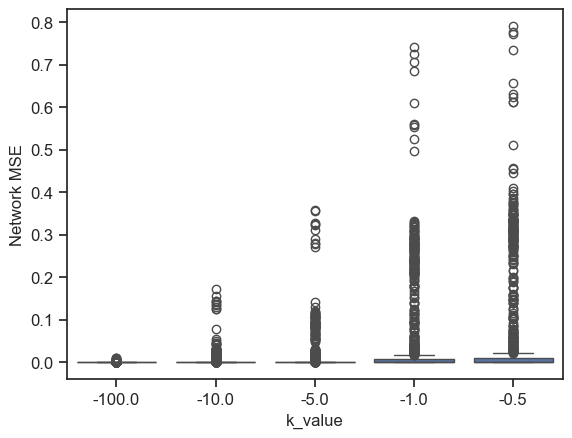

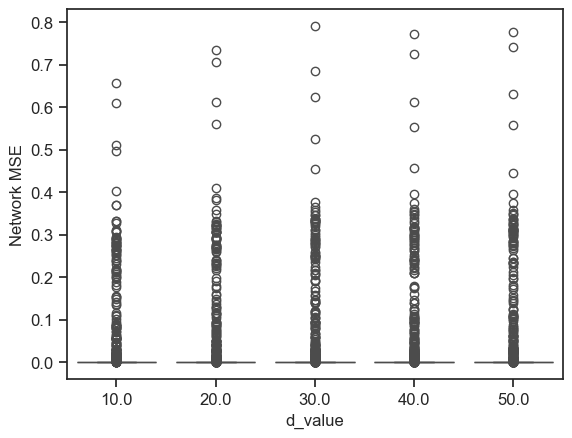

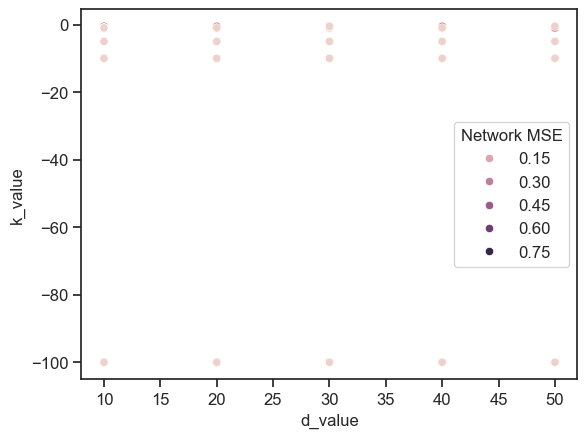

In [20]:
sns.boxplot(data=plt_perturb_mMSE[plt_perturb_mMSE["model"]=="student_division_same_input"], x="k_value", y='Network MSE')
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_params_mMSE_k.pdf", bbox_inches="tight")
plt.show()

sns.boxplot(data=plt_perturb_mMSE[plt_perturb_mMSE["model"]=="student_division_same_input"], x="d_value", y='Network MSE')
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_params_mMSE_d.pdf", bbox_inches="tight")
plt.show()

sns.scatterplot(data=plt_perturb_mMSE[plt_perturb_mMSE["model"]=="student_division_same_input"], x="d_value", hue='Network MSE', y="k_value")
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_params_k_d.pdf", bbox_inches="tight")
plt.show()

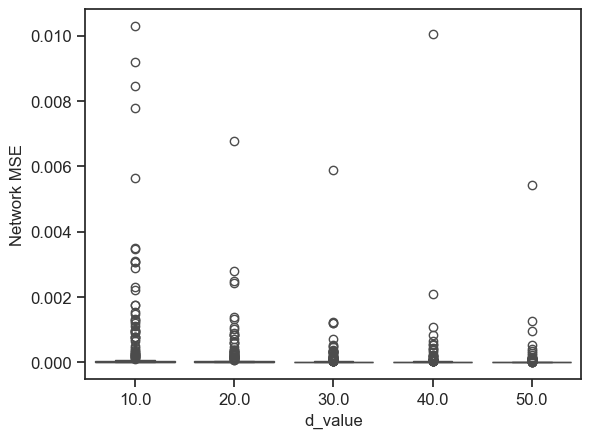

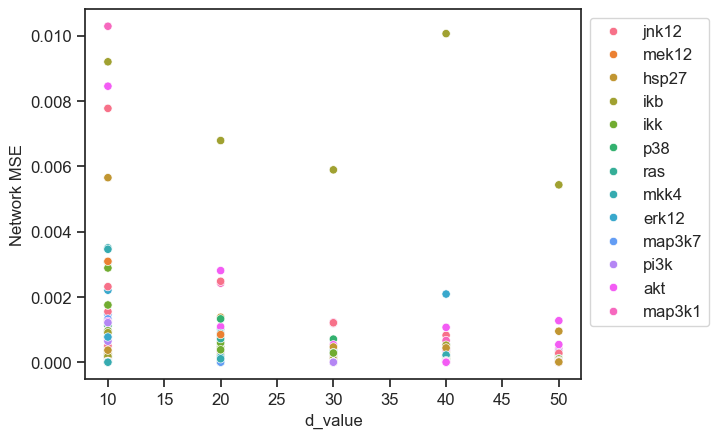

In [21]:
sns.boxplot(data=plt_perturb_mMSE[(plt_perturb_mMSE["model"]=="student_division_same_input")&
                                 (plt_perturb_mMSE["k_value"]==-100)], x="d_value", y='Network MSE')
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_student_div_k-100_params_mMSE_d.pdf", bbox_inches="tight")
plt.show()

sns.scatterplot(data=plt_perturb_mMSE[(plt_perturb_mMSE["model"]=="student_division_same_input")&
                                 (plt_perturb_mMSE["k_value"]==-100)], x="d_value", y='Network MSE', hue="node")
plt.legend(bbox_to_anchor=(1,1))
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_student_div_k-100_params_mMSE_d_node_color.pdf", bbox_inches="tight")
plt.show()


# Analyze selected result

In [22]:
d = 20
k = -10

In [23]:
sel_perturb_MSE = perturb_MSE[(perturb_MSE["d_value"]==d)&
                           (perturb_MSE["k_value"]==k)]
sel_unperturb_MSE = unperturb_MSE[(unperturb_MSE["d_value"]==d)& 
                               (unperturb_MSE["k_value"]==k)]

sel_perturb_R2 = perturb_R2[(perturb_R2["d_value"]==d)& 
                        (perturb_R2["k_value"]==k)]
sel_unperturb_R2 = unperturb_R2[(unperturb_R2["d_value"]==d)& 
                            (unperturb_R2["k_value"]==k)]


sel_perturb_MSE   = sel_perturb_MSE.drop(["k_value", "d_value"], axis=1)
sel_unperturb_MSE = sel_unperturb_MSE.drop(["k_value", "d_value"], axis=1)
sel_perturb_R2    = sel_perturb_R2.drop(["k_value", "d_value"], axis=1)
sel_unperturb_R2  = sel_unperturb_R2.drop(["k_value", "d_value"], axis=1)


In [24]:
sel_perturb_R2

,setting,repeat,inhibited_node,model,mek12,erk12,mkk4,jnk12,ikk,ikb,ras,map3k7,pi3k,map3k1,akt,p38,hsp27
3010,86.0,0.0,mek12,nohill_division_random_input,-0.633843,-0.009151,-1.045027,-0.969352,-1.827488,-3.081457,-0.722881,-1.142788,-0.728814,-0.915408,-0.624052,-1.041668,-0.984300
3011,86.0,0.0,mek12,nohill_division_same_input,0.894466,0.070411,0.217391,0.158057,0.154227,-1.159776,0.942457,0.711513,0.946778,0.785993,0.881921,-0.150967,-0.346993
3012,86.0,0.0,mek12,student_division_random_input,-0.611612,-0.011307,-0.950374,-0.883482,-1.688759,-2.921242,-0.693590,-1.041116,-0.766899,-0.816881,-0.662842,-0.957973,-0.908788
3013,86.0,0.0,mek12,student_division_same_input,1.000000,0.059708,0.999901,0.999926,0.999886,0.999883,1.000000,0.999649,0.999989,0.998977,0.999996,0.999918,0.999408
3014,86.0,0.0,mek12,teacher_division_random_input,-1.234925,-0.033758,-1.049392,-1.045558,-0.973868,-0.930376,-1.218246,-1.030816,-1.102420,-1.008905,-1.134968,-1.056944,-1.071727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5840,166.0,4.0,hsp27,student_division_random_input,-0.591998,-0.467177,-0.651176,-0.627353,-0.592166,-0.567174,-0.665013,-0.742086,-0.759762,-0.702756,-0.726795,-0.604042,-0.528004
5841,166.0,4.0,hsp27,student_division_same_input,1.000000,1.000000,0.999979,0.999994,0.999997,0.999998,1.000000,0.999984,0.999996,0.999992,0.999999,0.999972,0.999991
5842,166.0,4.0,hsp27,teacher_division_random_input,-0.900306,-0.891355,-1.043245,-1.057463,-1.079697,-1.081411,-0.900046,-1.106906,-0.935662,-1.014059,-0.993978,-1.033063,-1.009993
5843,166.0,4.0,hsp27,teacher_division_same_input,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
sel_perturb_data = perturb_data[(perturb_data["d_value"]==d)&
                        (perturb_data["k_value"]==k)]

sel_unperturb_data = unperturb_data[(unperturb_data["d_value"]==d)&
                        (unperturb_data["k_value"]==k)]


In [26]:
### TAKES LONG ###
# perturb_MMD = sel_data.groupby(["setting", "repeat", "k_value", "d_value", "inhibited_node"]).apply(compute_MMD, true_model_name="teacher_k_inhibition_true").reset_index().drop("level_5", axis=1).rename(columns={0: "MMD"})
# perturb_MMD.to_csv(f"{folder}results_perturbed_MMD_all_nodes.csv")
# unperturb_MMD = sel_unperturb_data.groupby(["setting", "repeat", "k_value", "d_value", "inhibited_node"]).apply(compute_MMD, true_model_name="teacher_no_pertrub_true").reset_index().drop("level_5", axis=1).rename(columns={0: "MMD"})
# unperturb_MMD.to_csv(f"{folder}results_unperturbed_MMD_all_nodes.csv")

# perturb_EMD = sel_data.groupby(["setting", "repeat", "k_value", "d_value", "inhibited_node"]).apply(compute_wasserstein, true_model_name="teacher_k_inhibition_true").reset_index().drop("level_5", axis=1).rename(columns={0: "EMD"})
# perturb_EMD.to_csv(f"{folder}results_perturbed_EMD_all_nodes.csv")
# unperturb_EMD = sel_unperturb_data.groupby(["setting", "repeat", "k_value", "d_value", "inhibited_node"]).apply(compute_wasserstein, true_model_name="teacher_no_pertrub_true").reset_index().drop("level_5", axis=1).rename(columns={0: "EMD"})
# unperturb_EMD.to_csv(f"{folder}results_unperturbed_EMD_all_nodes.csv")



In [27]:
sel_perturb_MMD   = pd.read_csv(f"{folder}results_perturbed_MMD_all_nodes.csv", index_col=0)
sel_unperturb_MMD = pd.read_csv(f"{folder}results_unperturbed_MMD_all_nodes.csv", index_col=0)
sel_perturb_EMD   = pd.read_csv(f"{folder}results_perturbed_EMD_all_nodes.csv", index_col=0)
sel_unperturb_EMD = pd.read_csv(f"{folder}results_unperturbed_EMD_all_nodes.csv", index_col=0)

In [28]:
sel_perturb_MMD

,setting,repeat,k_value,d_value,inhibited_node,model,MMD
0,170.0,0.0,-100.0,30.0,mek12,nohill_division_random_input,5.520191e-02
1,170.0,0.0,-100.0,30.0,mek12,nohill_division_same_input,5.265752e-02
2,170.0,0.0,-100.0,30.0,mek12,student_division_random_input,6.056554e-02
3,170.0,0.0,-100.0,30.0,mek12,student_division_same_input,5.144874e-05
4,170.0,0.0,-100.0,30.0,mek12,teacher_division_random_input,4.328440e-04
...,...,...,...,...,...,...,...
590,250.0,4.0,-100.0,30.0,hsp27,student_division_random_input,3.168748e-02
591,250.0,4.0,-100.0,30.0,hsp27,student_division_same_input,1.937151e-07
592,250.0,4.0,-100.0,30.0,hsp27,teacher_division_random_input,1.707253e-03
593,250.0,4.0,-100.0,30.0,hsp27,teacher_division_same_input,0.000000e+00


In [29]:
sel_perturb_MMD   = sel_perturb_MMD.drop(["k_value", "d_value"], axis=1)
sel_unperturb_MMD = sel_unperturb_MMD.drop(["k_value", "d_value"], axis=1)
sel_perturb_EMD   = sel_perturb_EMD.drop(["k_value", "d_value"], axis=1)
sel_unperturb_EMD = sel_unperturb_EMD.drop(["k_value", "d_value"], axis=1)

# R2, so same inputs

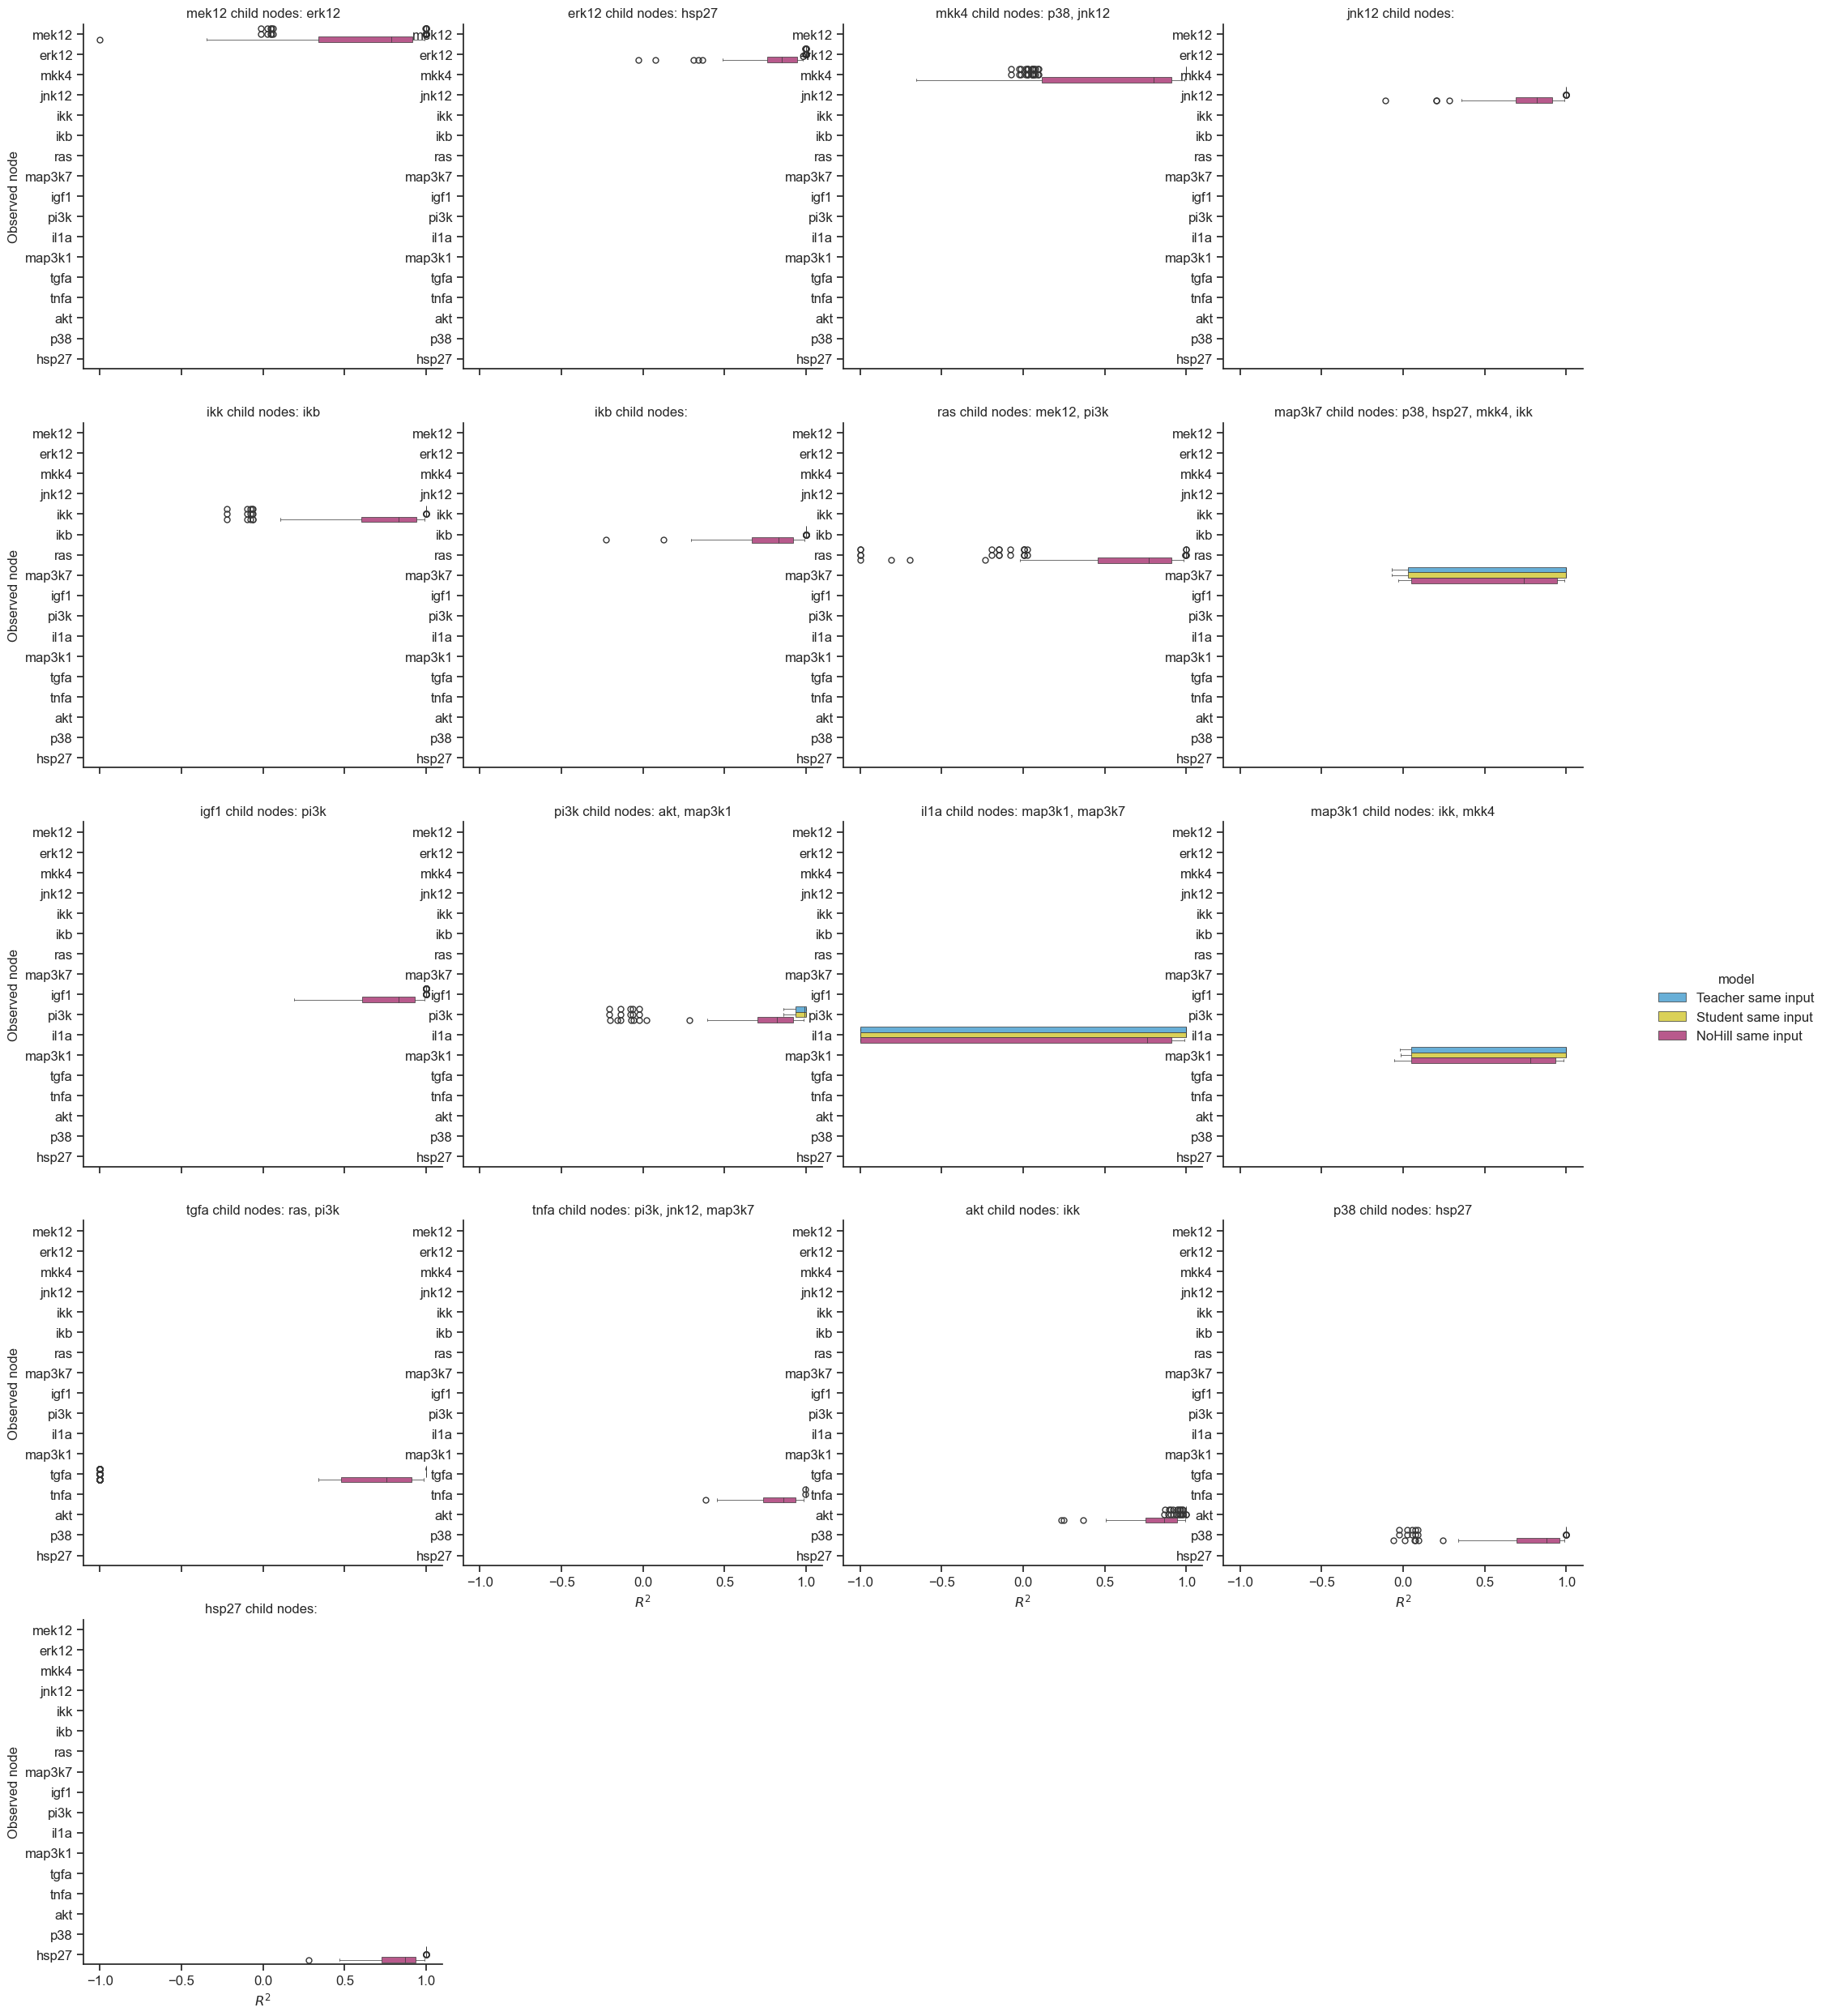

In [30]:
plt_data = sel_perturb_R2[["same" in m for m in sel_perturb_R2["model"]]]
plt_data = plt_data.melt(id_vars=["setting", "repeat", "model", "inhibited_node"], var_name="node", value_name="R2")
plt_data["Inhibited: "] = plt_data["inhibited_node"].map(child_dict)
temp = plt_data.copy()
temp.loc[temp["R2"]<-1, "R2"] = -1
g = sns.catplot(data=temp, y="inhibited_node", x="R2", col="Inhibited: ", 
                col_wrap=4, kind="box", hue="model", palette=perturbation_models_dict,
               linewidth=0.5, hue_order = ['teacher_division_same_input', 
                                           'student_division_same_input', 
                                           'nohill_division_same_input'])
g.set_titles(template='{col_name}')

for ax in g.axes.flatten():
    ax.tick_params(labelleft=True)
axes = g.axes.flatten()
axes[0].set_ylabel( "Observed node")
axes[4].set_ylabel( "Observed node")
axes[8].set_ylabel( "Observed node")
axes[12].set_ylabel("Observed node")
axes[16].set_ylabel("Observed node")

axes[13].set_xlabel("$R^2$")
axes[14].set_xlabel("$R^2$")
axes[15].set_xlabel("$R^2$")
axes[16].set_xlabel("$R^2$")

new_labels = ["Teacher same input", "Student same input", "NoHill same input"]
for t, l in zip(g.legend.texts, new_labels):
    t.set_text(l)
    
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_R2_same_inputs.pdf", bbox_inches="tight")
plt.show()

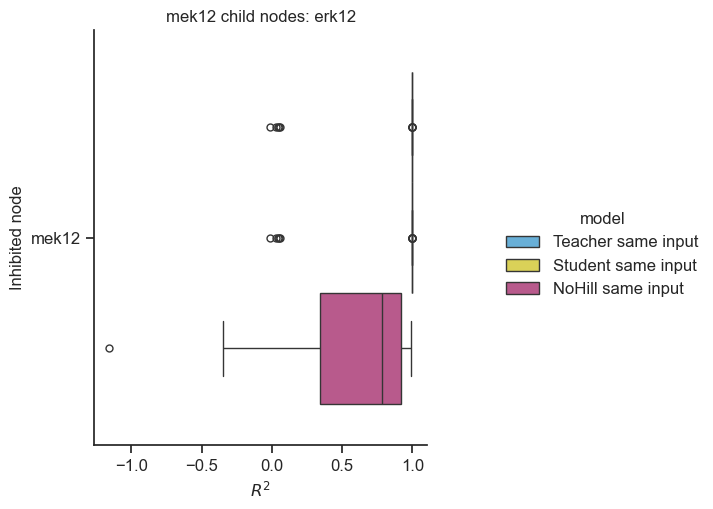

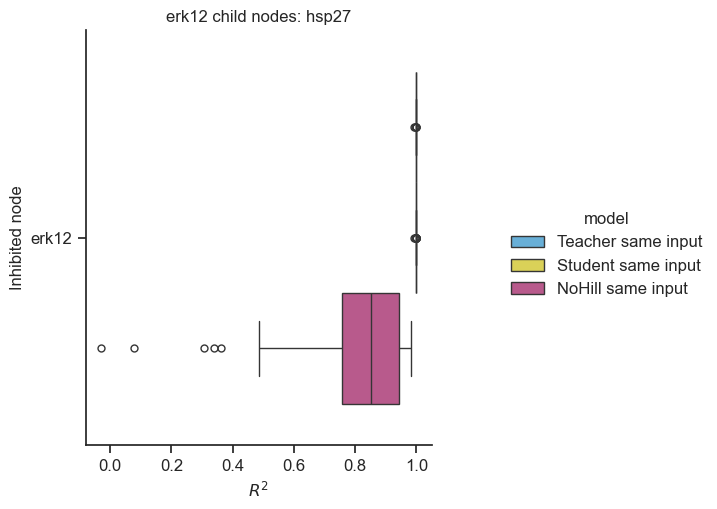

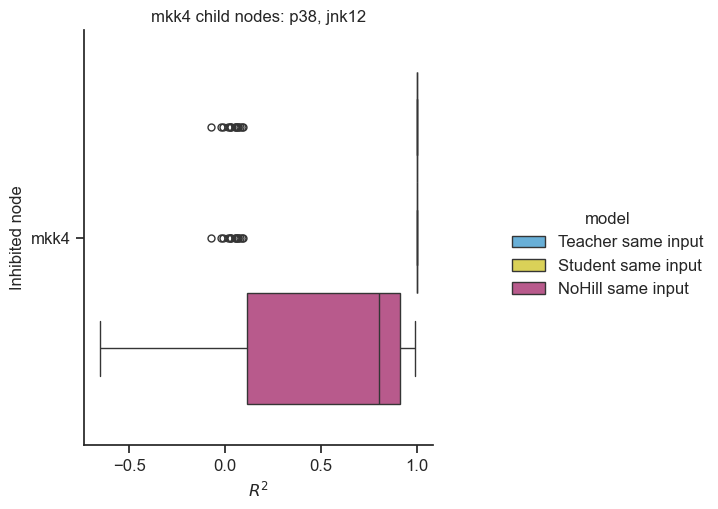

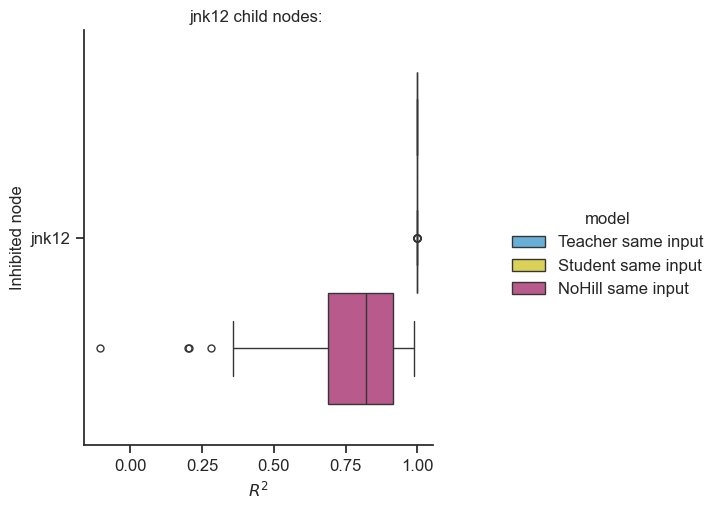

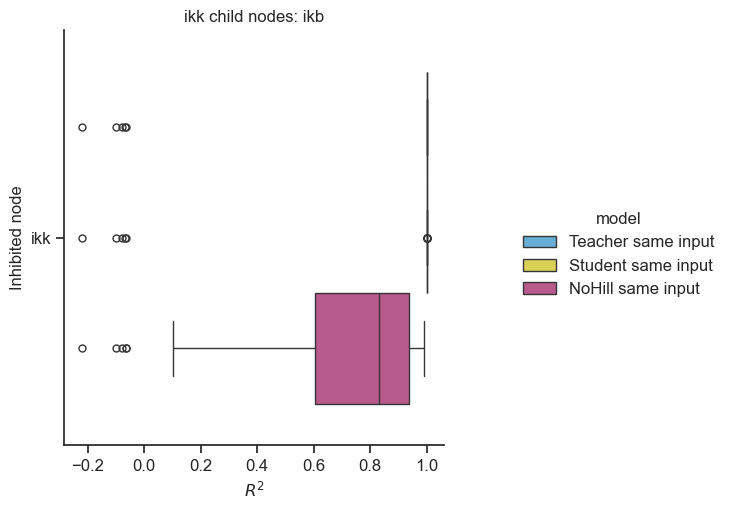

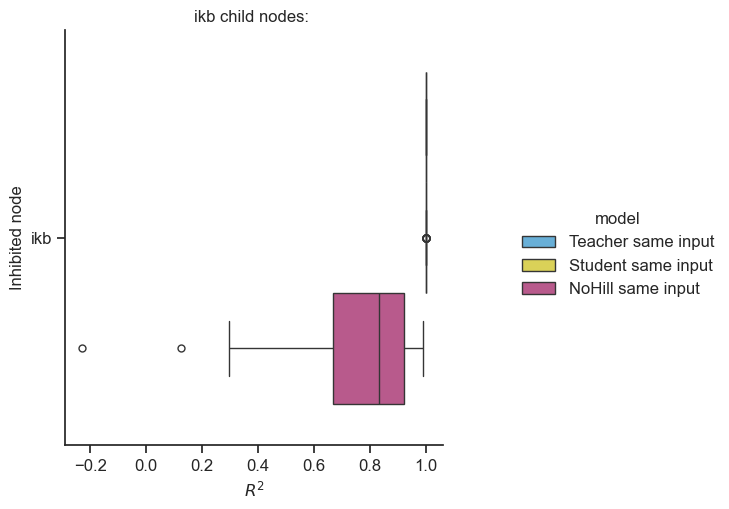

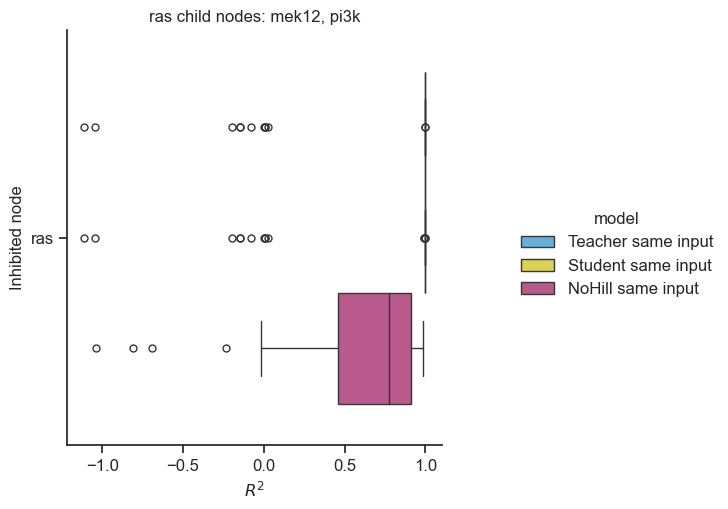

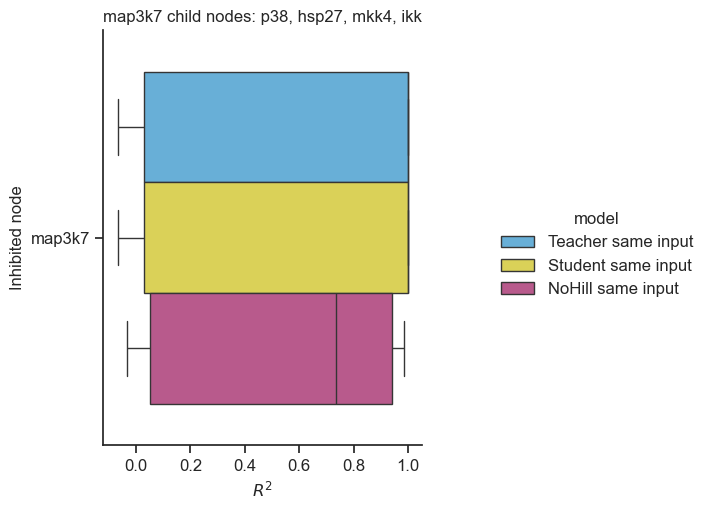

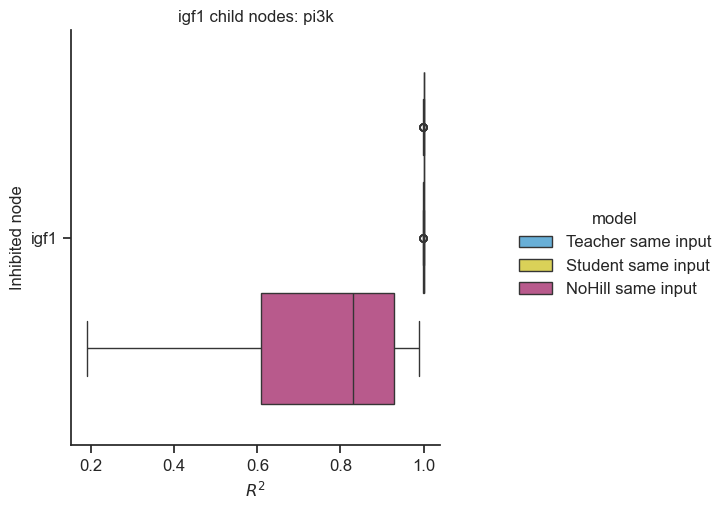

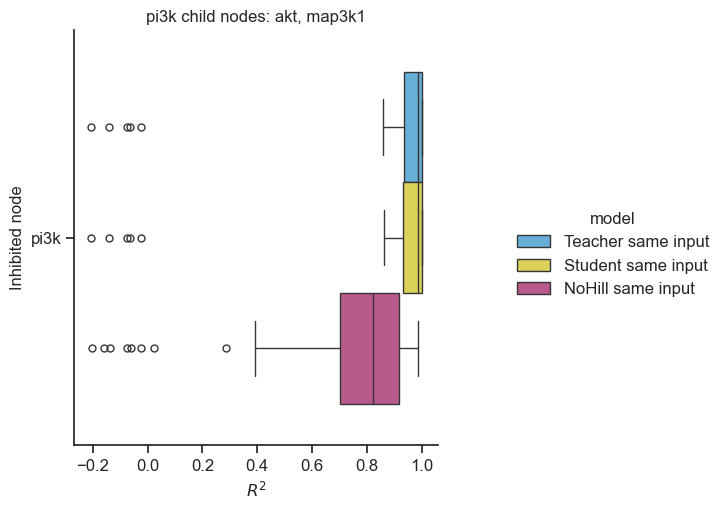

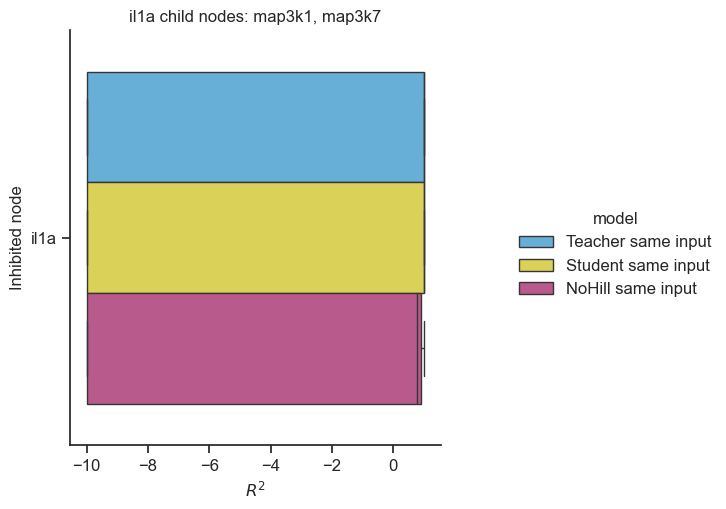

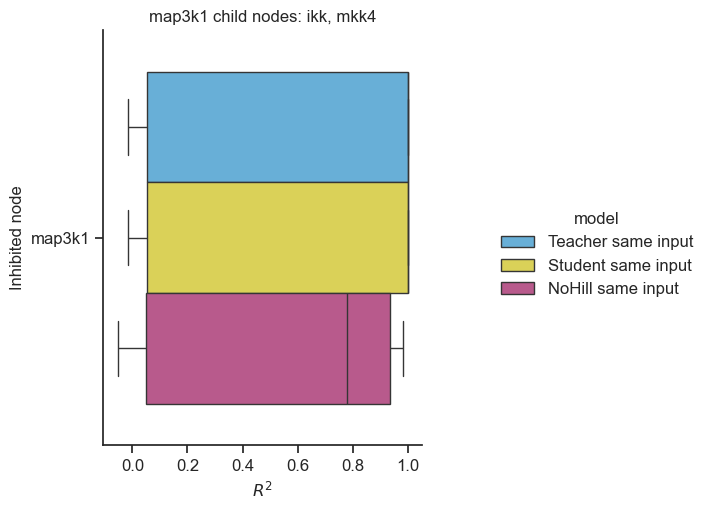

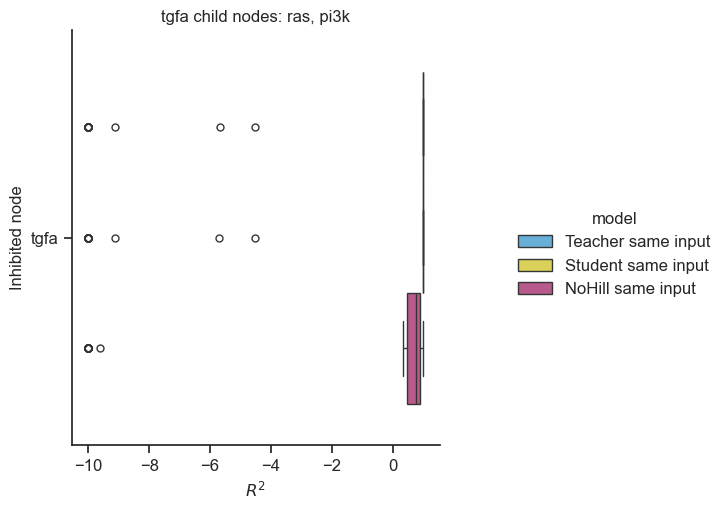

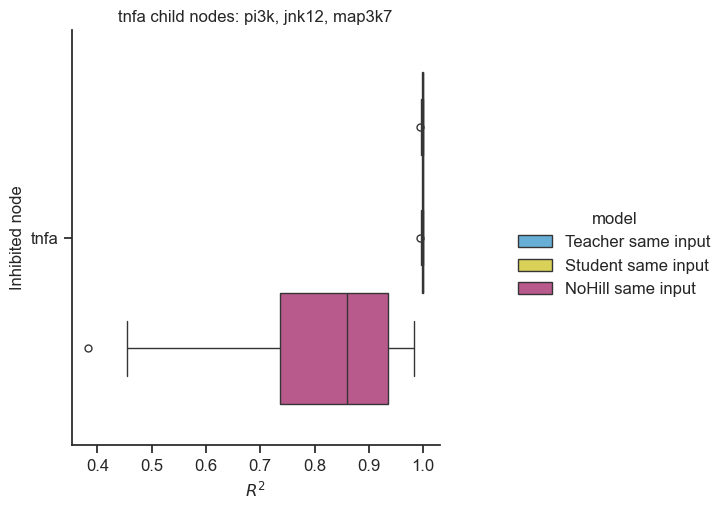

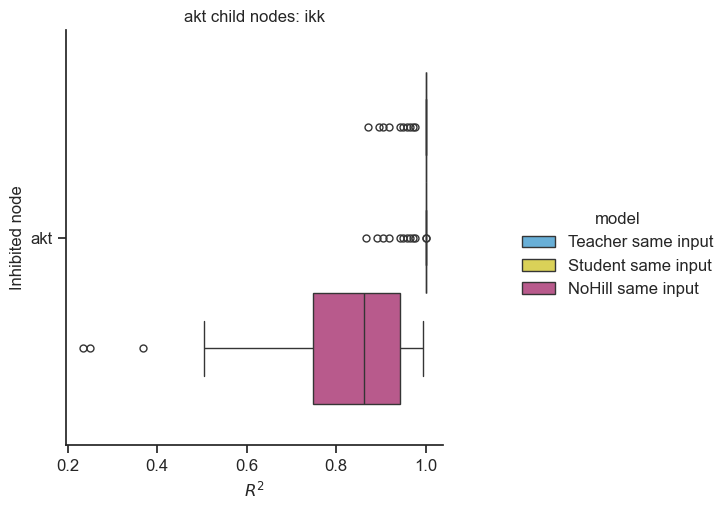

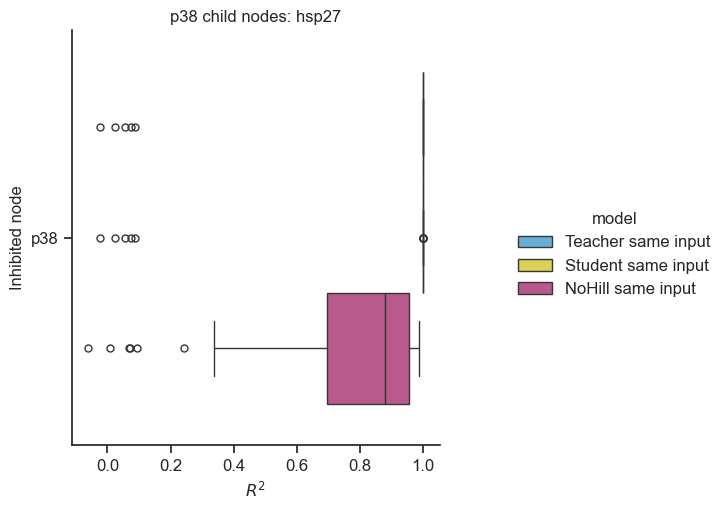

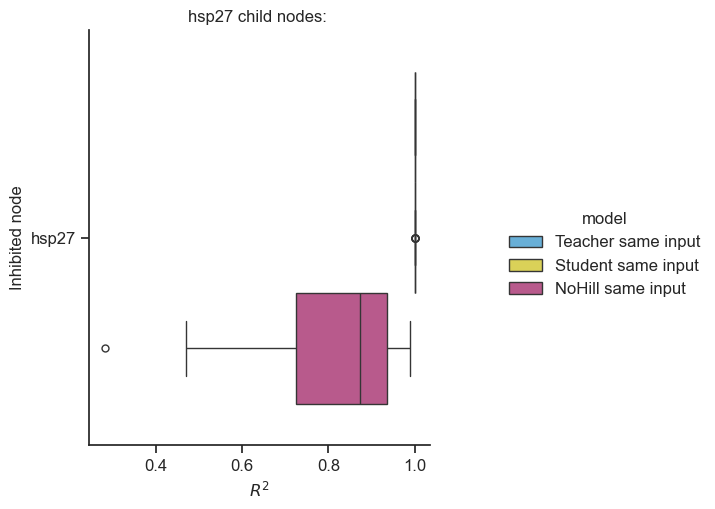

In [31]:
for n in plt_data["inhibited_node"].unique():
    temp = plt_data[plt_data["inhibited_node"]==n]
    temp.loc[temp["R2"]<-10, "R2"] = -10
    g = sns.catplot(data=temp, y="inhibited_node", x="R2", kind="box", hue="model", palette=perturbation_models_dict, 
              hue_order = ['teacher_division_same_input', 'student_division_same_input', 'nohill_division_same_input'])
    plt.title(temp["Inhibited: "].unique()[0])
    plt.ylabel("Inhibited node")
    new_labels = ["Teacher same input", "Student same input", "NoHill same input"]
    for t, l in zip(g._legend.texts, new_labels):
        t.set_text(l)
    plt.xlabel("$R^2$")
    plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_R2_same_inputs_{n}_inhibited.pdf", bbox_inches="tight")
    plt.show()

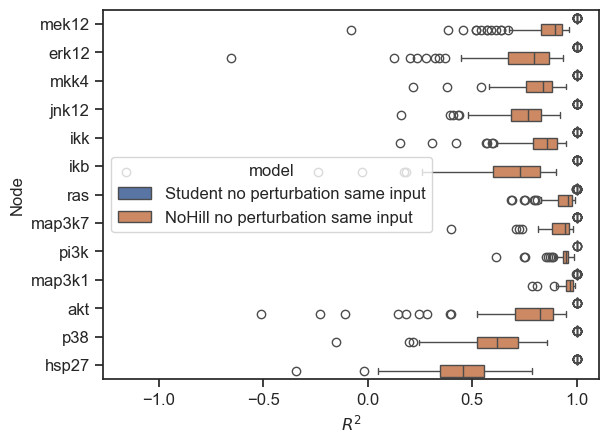

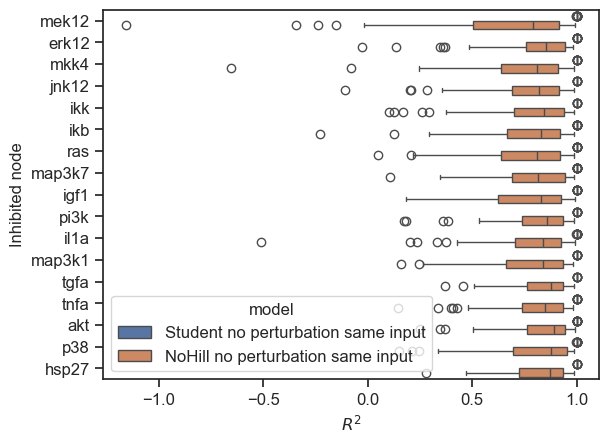

In [32]:
# In unperturbed data, there is no inhibition so all settings are the same (inhibited node doesn't matter)
plt_data = sel_unperturb_R2[["same" in m for m in sel_unperturb_R2["model"]]]
plt_data = plt_data.melt(id_vars=["setting", "repeat", "model", "inhibited_node"], var_name="node", value_name="R2")
g = sns.boxplot(data = plt_data, y="node", x="R2", hue="model", 
                hue_order=["student_no_perturb_same_input", "nohill_no_perturb_same_input"])
plt.ylabel("Node")
new_labels = ["Student no perturbation same input", "NoHill no perturbation same input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.xlabel("$R^2$")
plt.show()

g = sns.boxplot(data = plt_data, y="inhibited_node", x="R2", hue="model", 
                hue_order=["student_no_perturb_same_input", "nohill_no_perturb_same_input"])
plt.ylabel("Inhibited node")
new_labels = ["Student no perturbation same input", "NoHill no perturbation same input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.xlabel("$R^2$")
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_R2_same_inputs_no_perturbation.pdf", bbox_inches="tight")
plt.show()


# MMD div, so unmatched inputs

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/1877932995.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plt_data["Inhibited: "] = plt_data["inhibited_node"].map(child_dict)


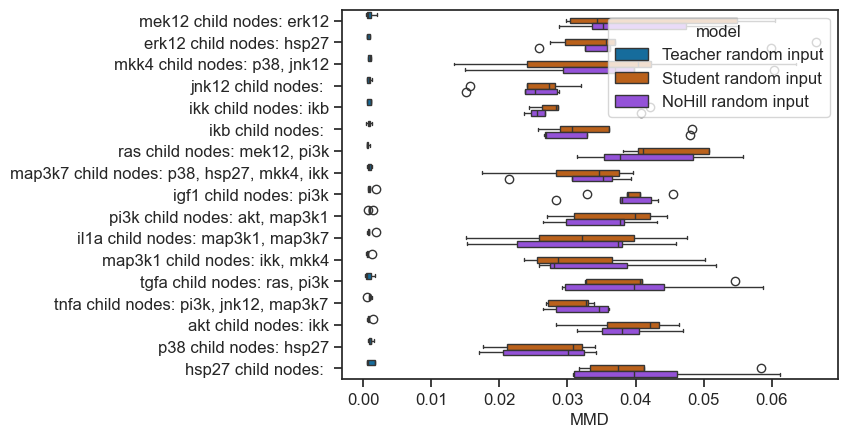

In [33]:
plt_data = sel_perturb_MMD[["random" in m for m in sel_perturb_MMD["model"]]]
plt_data["Inhibited: "] = plt_data["inhibited_node"].map(child_dict)
g=sns.boxplot(data=plt_data, y="Inhibited: ", x="MMD", hue="model", palette=perturbation_models_dict, 
            hue_order=["teacher_division_random_input", "student_division_random_input", "nohill_division_random_input"])

new_labels = ["Teacher random input", "Student random input", "NoHill random input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.ylabel("")

plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_MMD_random_inputs.pdf", bbox_inches="tight")
plt.show()

## MMD on matched inputs

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/1013951780.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plt_data["Inhibited: "] = plt_data["inhibited_node"].map(child_dict)


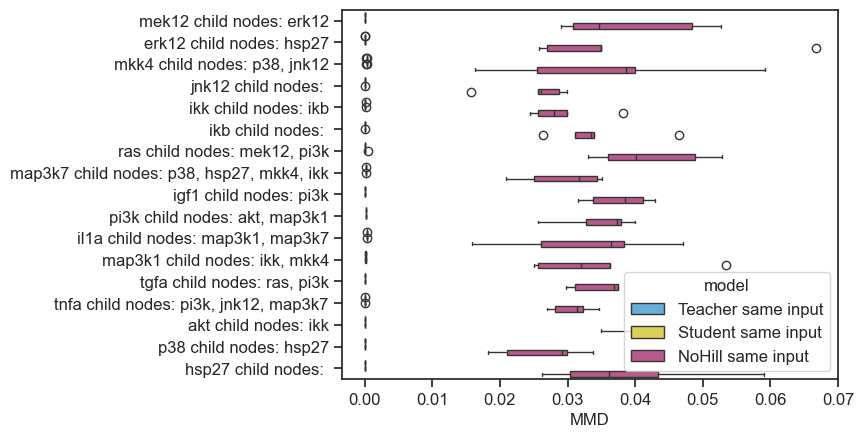

In [34]:
plt_data = sel_perturb_MMD[["same" in m for m in sel_perturb_MMD["model"]]]
plt_data["Inhibited: "] = plt_data["inhibited_node"].map(child_dict)

g=sns.boxplot(data=plt_data, y="Inhibited: ", x="MMD", hue="model", palette=perturbation_models_dict, 
            hue_order=["teacher_division_same_input", "student_division_same_input", "nohill_division_same_input"])
new_labels = ["Teacher same input", "Student same input", "NoHill same input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.ylabel("")
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_MMD_same_inputs.pdf", bbox_inches="tight")
plt.show()

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/985299907.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set(yticklabels=["Student no perturbation random input", "NoHill no perturbation random input"])


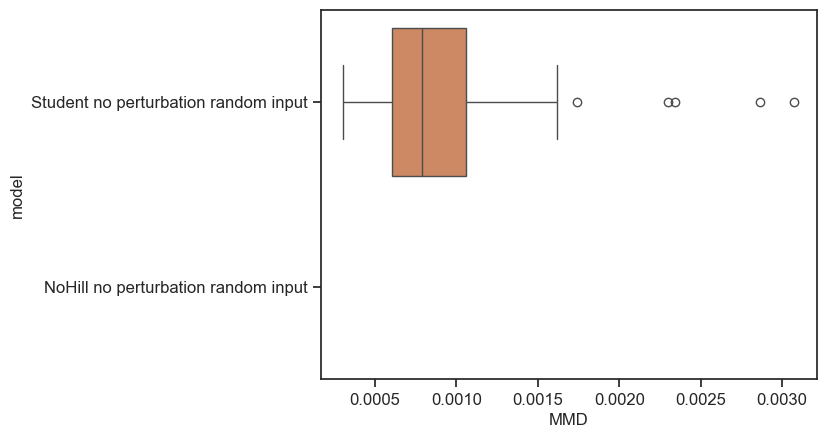

In [35]:
# In unperturbed data, there is no inhibition so all settings are the same (inhibited node doesn't matter)
plt_data = sel_unperturb_MMD[["random" in m for m in sel_unperturb_MMD["model"]]]
g = sns.boxplot(data=plt_data, y="model", x="MMD", hue="model", 
                order=["student_no_perturb_random_input", "nohill_no_perturba_random_input"])
g.set(yticklabels=["Student no perturbation random input", "NoHill no perturbation random input"])
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_MMD_random_inputs_no_perturb.pdf", bbox_inches="tight")
plt.show()

# EMD, unmatched input

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/589157624.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plt_data["Inhibited: "] = plt_data["inhibited_node"]#.map(child_dict)


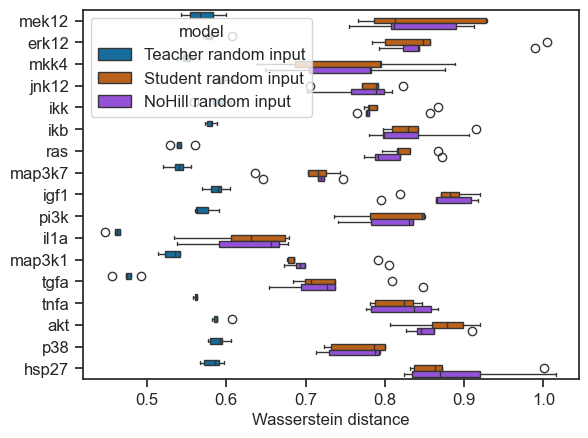

In [36]:
plt_data = sel_perturb_EMD[["random" in m for m in sel_perturb_EMD["model"]]]
plt_data["Inhibited: "] = plt_data["inhibited_node"]#.map(child_dict)
g=sns.boxplot(data=plt_data, y="Inhibited: ", x="EMD", hue="model", palette=perturbation_models_dict, 
            hue_order=["teacher_division_random_input", "student_division_random_input", "nohill_division_random_input"])
t = plt.xlabel("Wasserstein distance")
new_labels = ["Teacher random input", "Student random input", "NoHill random input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.ylabel("")  
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_EMD_random_inputs.pdf", bbox_inches="tight")
plt.show()

## EMD same inputs

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/2766605385.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plt_data["Inhibited: "] = plt_data["inhibited_node"]#.map(child_dict)


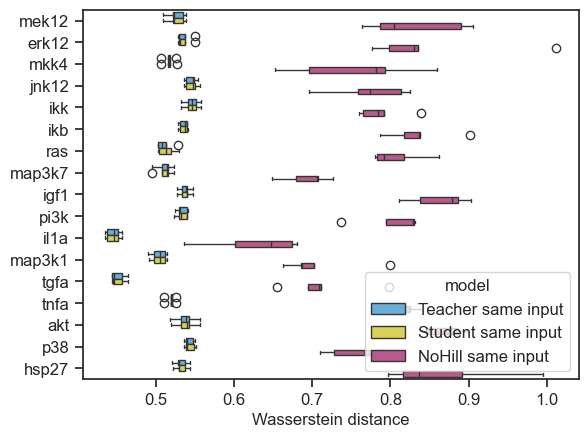

In [37]:
plt_data = sel_perturb_EMD[["same" in m for m in sel_perturb_EMD["model"]]]
plt_data["Inhibited: "] = plt_data["inhibited_node"]#.map(child_dict)

g=sns.boxplot(data=plt_data, y="Inhibited: ", x="EMD", hue="model", palette=perturbation_models_dict, 
            hue_order=["teacher_division_same_input", "student_division_same_input", "nohill_division_same_input"])
t = plt.xlabel("Wasserstein distance")
new_labels = ["Teacher same input", "Student same input", "NoHill same input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.ylabel("")

plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_EMD_same_inputs.pdf", bbox_inches="tight")
plt.show()

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/1195656580.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set(yticklabels=["Student no perturbation random input", "NoHill no perturbation random input"])


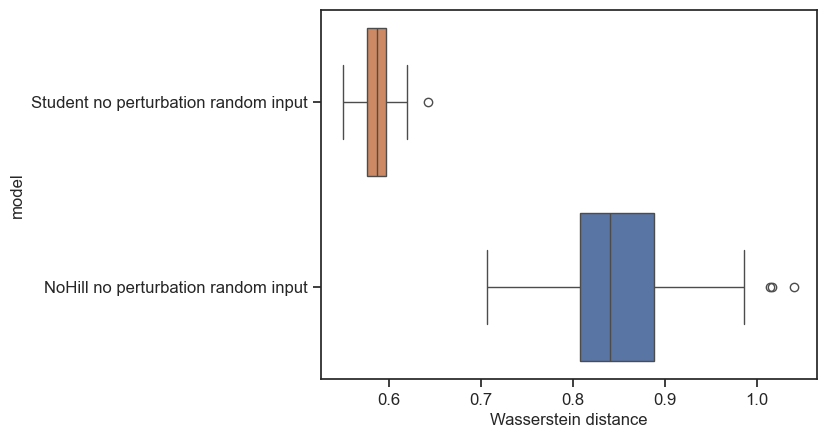

In [38]:
# In unperturbed data, there is no inhibition so all settings are the same (inhibited node doesn't matter)
plt_data = sel_unperturb_EMD[["random" in m for m in sel_unperturb_EMD["model"]]]
g=sns.boxplot(data=plt_data, y="model", x="EMD", hue="model",
             order=["student_no_perturb_random_input", "nohill_no_perturb_random_input"])
t = plt.xlabel("Wasserstein distance")
g.set(yticklabels=["Student no perturbation random input", "NoHill no perturbation random input"])
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_EMD_random_inputs_no_perturb.pdf", bbox_inches="tight")
t = plt.xlabel("Wasserstein distance")

plt.show()

# MSE, so matched input

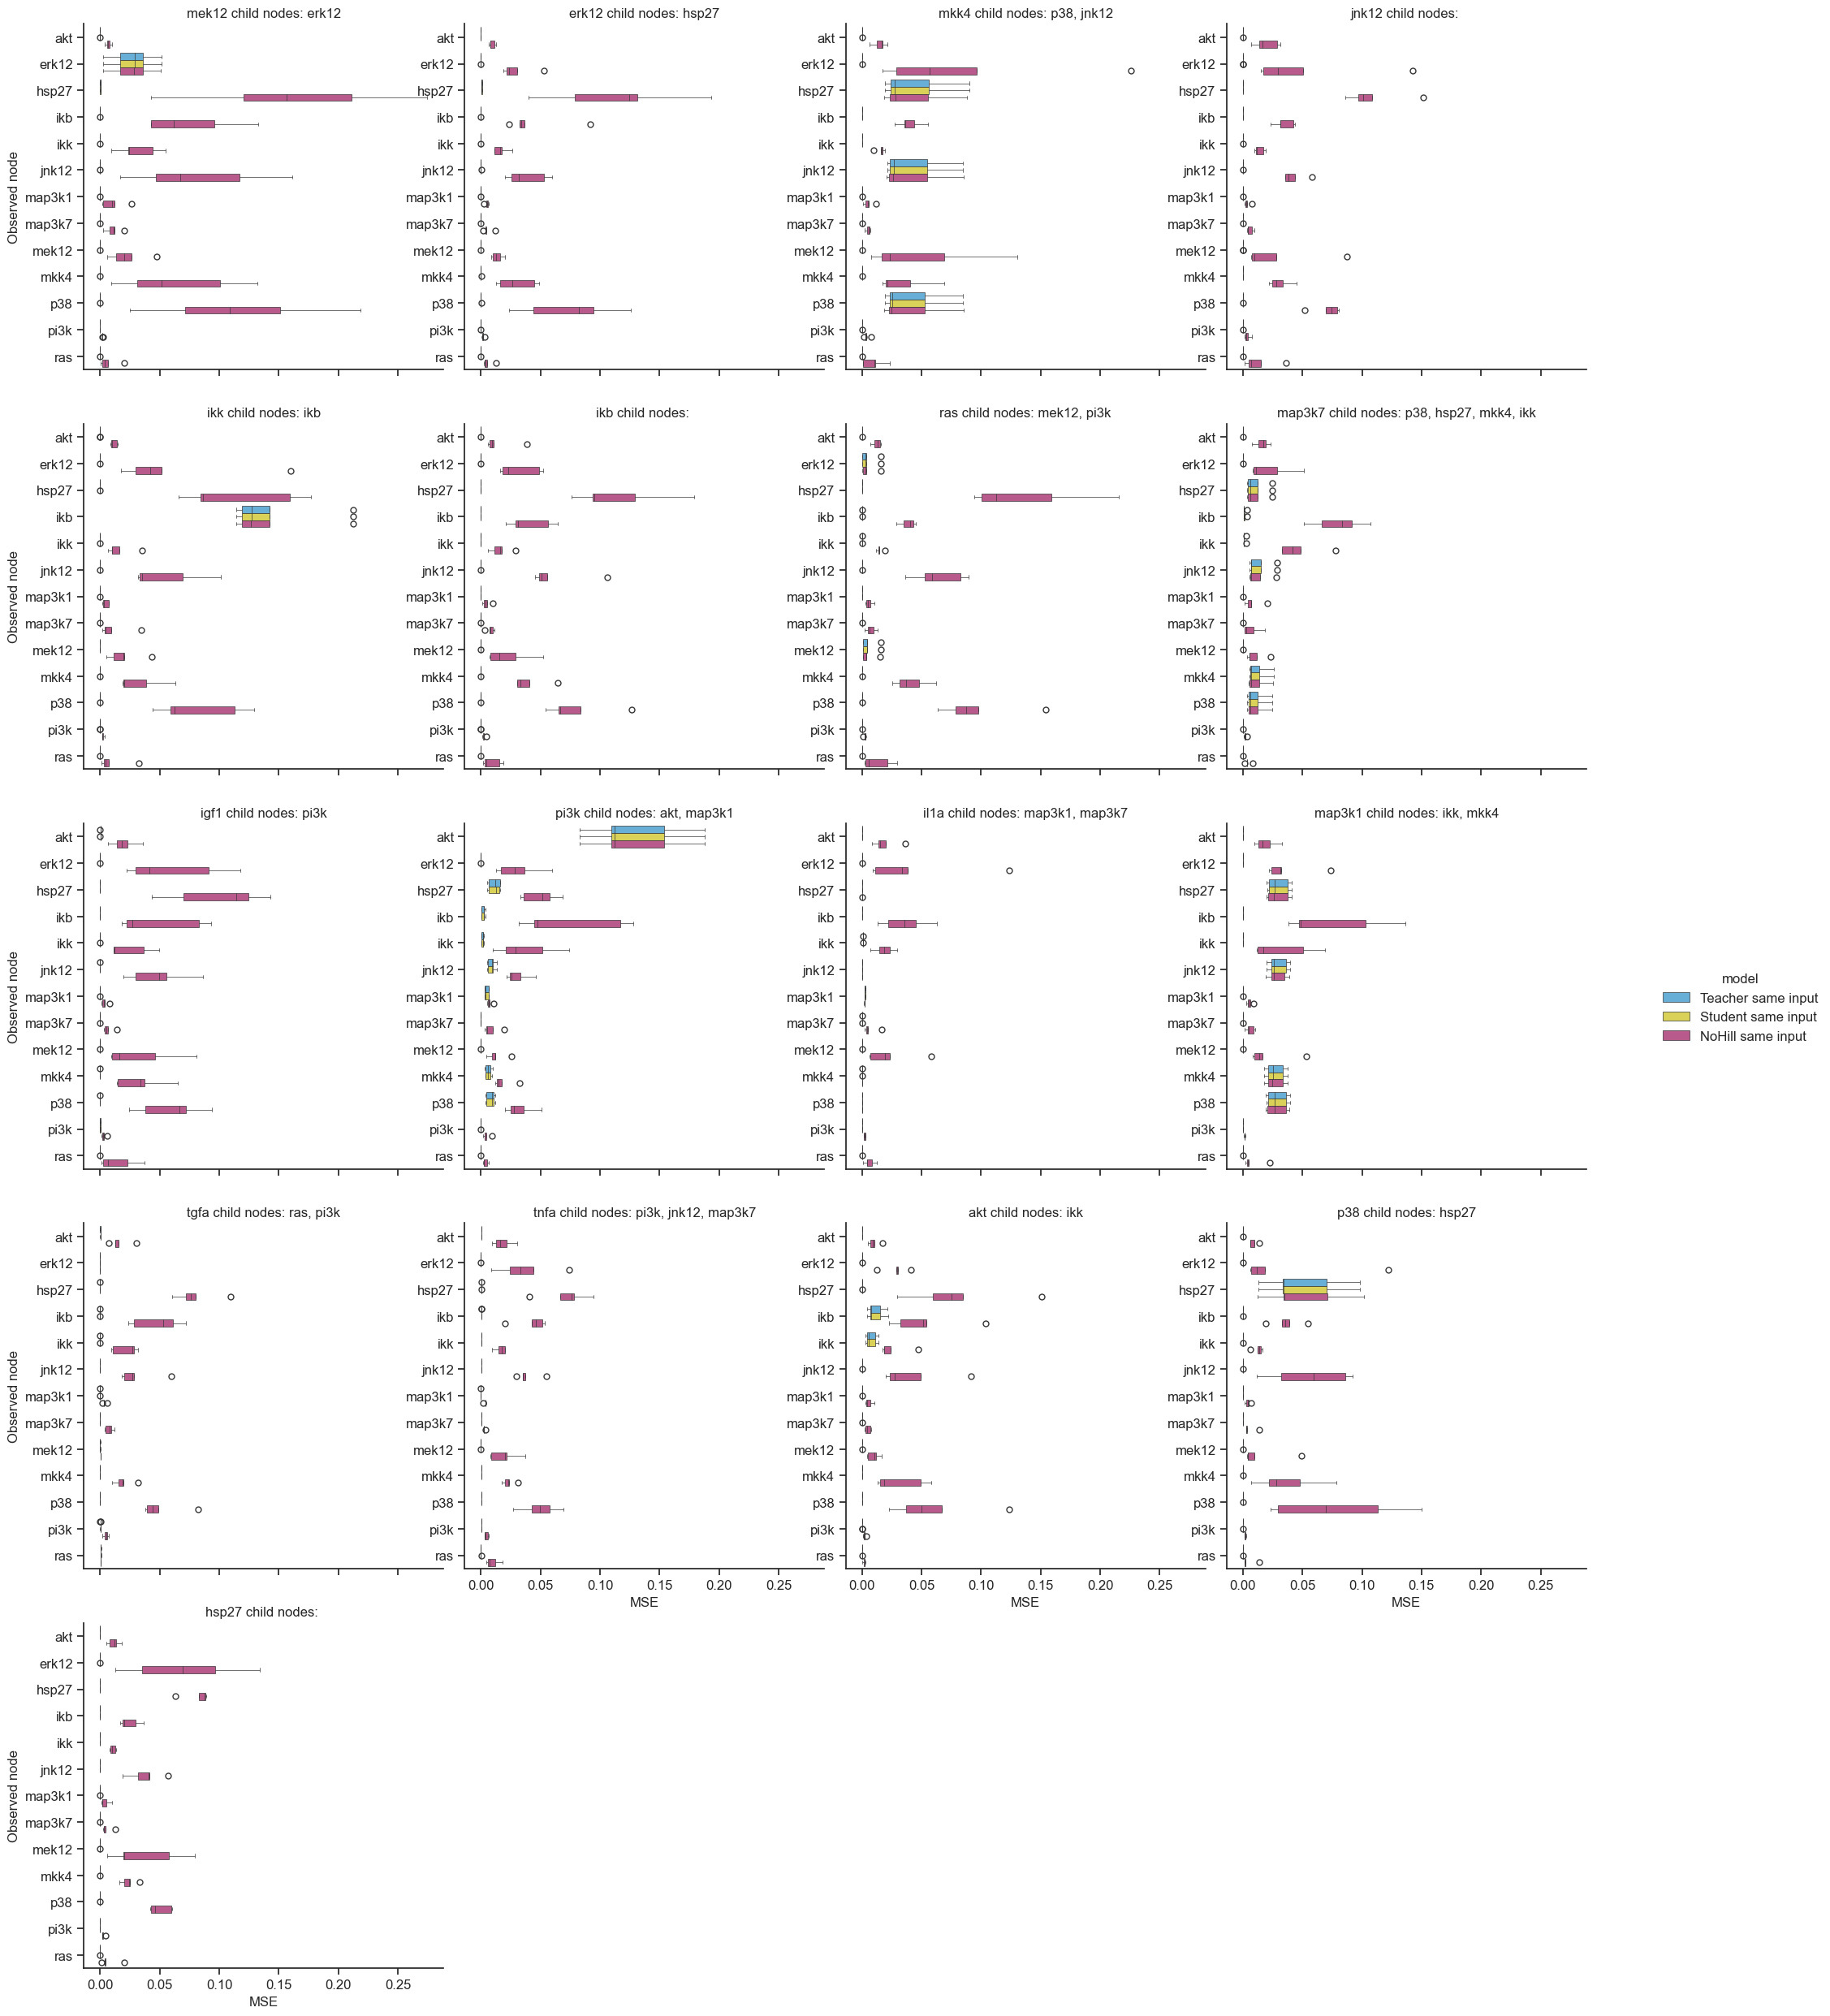

In [39]:
plt_data = sel_perturb_MSE[["same" in m for m in sel_perturb_MSE["model"]]]
plt_data = plt_data.melt(id_vars=["setting", "repeat", "model", "inhibited_node"], var_name="node", value_name="MSE")
plt_data["Inhibited: "] = plt_data["inhibited_node"].map(child_dict)
g = sns.catplot(data=plt_data, y="node", x="MSE", col="Inhibited: ", 
                col_wrap=4, kind="box", hue="model", palette=perturbation_models_dict,
               linewidth=0.5, hue_order=["teacher_division_same_input", "student_division_same_input", "nohill_division_same_input"])
new_labels = ["Teacher same input", "Student same input", "NoHill same input"]
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
    
g.set_titles(template='{col_name}')
for ax in g.axes.flatten():
    ax.tick_params(labelleft=True)
axes = g.axes.flatten()
axes[0].set_ylabel( "Observed node")
axes[4].set_ylabel( "Observed node")
axes[8].set_ylabel( "Observed node")
axes[12].set_ylabel("Observed node")
axes[16].set_ylabel("Observed node")

plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_MSE_same_inputs.pdf", bbox_inches="tight")
plt.show()

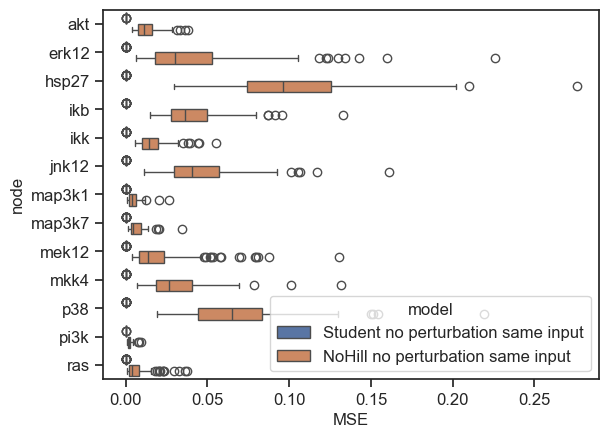

In [40]:
# In unperturbed data, there is no inhibition so all settings are the same (inhibited node doesn't matter)
plt_data = sel_unperturb_MSE[["same" in m for m in sel_unperturb_MSE["model"]]]
plt_data = plt_data.melt(id_vars=["setting", "repeat", "model", "inhibited_node"], var_name="node", value_name="MSE")
g = sns.boxplot(data=plt_data, y="node", x="MSE", hue="model", 
                hue_order=["student_no_perturb_same_input", "nohill_no_perturb_same_input"])
new_labels = ["Student no perturbation same input", "NoHill no perturbation same input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.savefig(f"/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_MSE_same_inputs_no_perturb.pdf", bbox_inches="tight")
plt.show()

In [41]:
perturb_MSE["model"].unique()

array(['nohill_division_random_input', 'nohill_division_same_input',
       'student_division_random_input', 'student_division_same_input',
       'teacher_division_random_input', 'teacher_division_same_input',
       'teacher_k_inhibition_true'], dtype=object)

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/1831966516.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(data=plt_data, y="model", x="MSE", palette=perturbation_models_dict,
/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/1831966516.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set(yticklabels=["Teacher same input", "Student same input", "NoHill same input"])


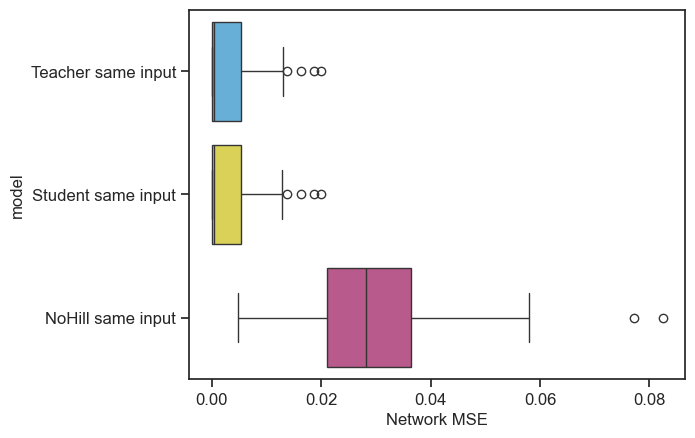

In [42]:
plt_data = sel_perturb_MSE.melt(id_vars=["setting", "repeat", "inhibited_node", "model"], 
                            var_name="predicted_node", value_name="MSE")
plt_data = plt_data.groupby(["setting", 
                             "repeat", 
                             "inhibited_node", 
                             "model"]).mean(numeric_only=True).reset_index()
plt_data= plt_data[plt_data["model"].isin(['student_division_same_input', 
                                           'nohill_division_same_input', 
                                           'teacher_division_same_input'])]
g = sns.boxplot(data=plt_data, y="model", x="MSE", palette=perturbation_models_dict, 
                order = ['teacher_division_same_input', 
                         'student_division_same_input', 
                         'nohill_division_same_input'])
t = plt.xlabel("Network MSE")
g.set(yticklabels=["Teacher same input", "Student same input", "NoHill same input"])
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_network_MSE.pdf",
           bbox_inches="tight")

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/3774083498.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g= sns.boxplot(data=plt_data, y="model", x="R2", palette=perturbation_models_dict,
/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/3774083498.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set(yticklabels=["Teacher same input", "Student same input", "NoHill same input"])


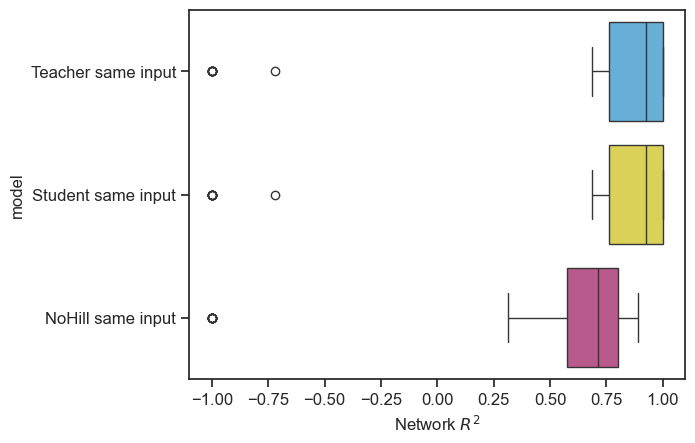

In [43]:
plt_data = sel_perturb_R2.melt(id_vars=["setting", "repeat", "inhibited_node", "model"], 
                            var_name="predicted_node", value_name="R2")
plt_data = plt_data.groupby(["setting", 
                             "repeat", 
                             "inhibited_node", 
                             "model"]).mean(numeric_only=True).reset_index()
plt_data= plt_data[plt_data["model"].isin(['student_division_same_input', 
                                           'nohill_division_same_input', 
                                           'teacher_division_same_input'])]
plt_data.loc[plt_data["R2"]<-1, "R2"] = -1

g= sns.boxplot(data=plt_data, y="model", x="R2", palette=perturbation_models_dict, 
               order = ['teacher_division_same_input', 
                        'student_division_same_input', 
                        'nohill_division_same_input'])
t = plt.xlabel("Network $R^2$")
g.set(yticklabels=["Teacher same input", "Student same input", "NoHill same input"])
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_network_R2.pdf",
           bbox_inches="tight")

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/1548617072.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(data=plt_data, y="model", x="MMD", palette=perturbation_models_dict,
/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/1548617072.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set(yticklabels=["Teacher same input", "Student same input", "NoHill same input",


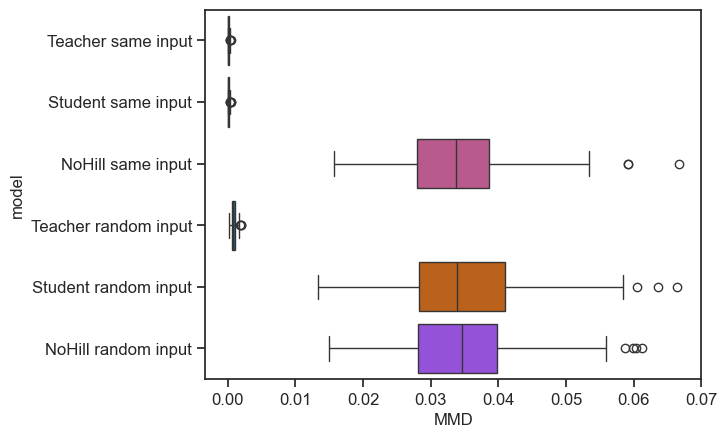

In [44]:
plt_data= sel_perturb_MMD[sel_perturb_MMD["model"].isin(['student_division_same_input', 
                                           'nohill_division_same_input', 
                                           'teacher_division_same_input',
                                           'student_division_random_input', 
                                           'nohill_division_random_input', 
                                           'teacher_division_random_input'])]

g = sns.boxplot(data=plt_data, y="model", x="MMD", palette=perturbation_models_dict, 
                order=['teacher_division_same_input', 
                       'student_division_same_input', 
                       'nohill_division_same_input',
                       'teacher_division_random_input', 
                       'student_division_random_input', 
                       'nohill_division_random_input'])
g.set(yticklabels=["Teacher same input", "Student same input", "NoHill same input", 
                   "Teacher random input", "Student random input", "NoHill random input"])
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_MMD_same_and_random_inputs.pdf",
           bbox_inches="tight")

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/559582991.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(data=plt_data, y="model", x="EMD", palette=perturbation_models_dict,
/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_63893/559582991.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set(yticklabels=["Teacher same input", "Student same input", "NoHill same input",


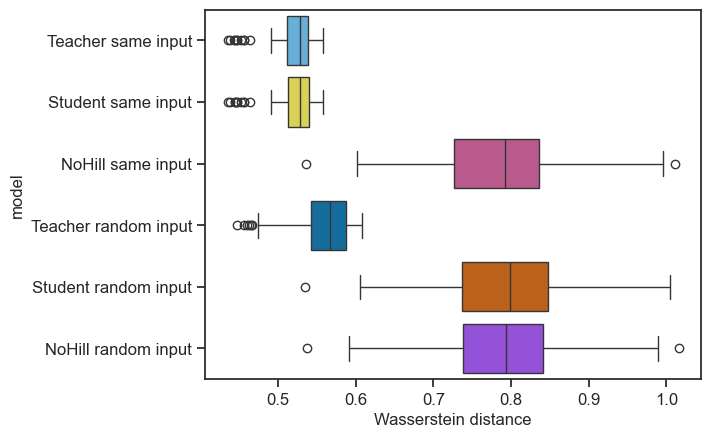

In [45]:
plt_data= sel_perturb_EMD[sel_perturb_EMD["model"].isin(['teacher_division_same_input', 
                                           'student_division_same_input', 
                                           'nohill_division_same_input',
                                           'teacher_division_random_input', 
                                           'student_division_random_input', 
                                           'nohill_division_random_input'])]
g = sns.boxplot(data=plt_data, y="model", x="EMD", palette=perturbation_models_dict, 
                order=['teacher_division_same_input', 
                       'student_division_same_input', 
                       'nohill_division_same_input',
                       'teacher_division_random_input', 
                       'student_division_random_input', 
                       'nohill_division_random_input'])
t=plt.xlabel("Wasserstein distance")
g.set(yticklabels=["Teacher same input", "Student same input", "NoHill same input", 
                   "Teacher random input", "Student random input", "NoHill random input"])
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Syntehtic_perturb_EMD_same_and_random_inputs.pdf",
           bbox_inches="tight")